# Investigate a Dataset - IMDB

## Table of Contents
<ul>
<li><a href="#intro">Introduction</a></li>
<li><a href="#wrangling">Data Wrangling</a></li>
<li><a href="#eda">Exploratory Data Analysis</a></li>
<li><a href="#conclusions">Conclusions</a></li>
</ul>

<a id='intro'></a>
## Introduction

### Dataset Description 

The dataset I selected for this project is the TMDb movie dataset, which contains information about approximately 10,000 movies collected from The Movie Database (TMDb). It consists of a single table containing the following 21 columns:

**id**
A unique numeric identifier assigned to each movie by The Movie Database (TMDb), serving as the primary key.

**imdb_id**
The unique identifier string for the movie on the Internet Movie Database (IMDb).

**popularity**
A numeric score measuring the popularity of the movie on TMDb.

**budget**
The estimated cost of producing the movie in US Dollars (nominal value).

**revenue**
The worldwide box office earnings of the movie in US Dollars (nominal value).

**original_title**
The title of the movie in its original language.

**cast**
A pipe-separated list of the main actors starring in the movie.

**homepage**
The website URL for the movie's official homepage.

**director**
A pipe-separated list of the director(s) of the movie.

**tagline**
A short, promotional catchphrase or slogan associated with the movie.

**keywords**
A pipe-separated list of thematic keywords or plot tags.

**overview**
A short synopsis or summary describing the movie's plot.

**runtime**
The total duration of the movie in minutes.

**genres**
A pipe-separated list of genres the movie belongs to.

**production_companies**
A pipe-separated list of production companies or studios that made the movie.

**release_date**
The calendar date the movie was officially released.

**vote_count**
The total number of user ratings and votes the movie received on TMDb.

**vote_average**
The average user rating score of the movie on TMDb (on a scale from 0 to 10).

**release_year**
The year the movie was released (extracted from the release date).

**budget_adj**
The production budget adjusted for inflation (using 2010 as a base year).

**revenue_adj**
The worldwide revenue adjusted for inflation (using 2010 as a base year).



### Question(s) for Analysis
**1: How do a film's budget, runtime, and popularity impact its revenue?**

**2: Which movie genres are the most popular, and which ones generate the highest average adjusted revenue?**

**3: Has the average runtime of movies changed over the years, and is there a correlation between runtime and viewer ratings?**

**4: Do movies with higher budgets tend to receive higher viewer ratings, or is popularity a better indicator of rating quality?**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

<a id='wrangling'></a>
## Data Wrangling


### General Properties

Here I load the data into a DataFrame and print out a few lines using head().

In [2]:
df = pd.read_csv('./tmdb-movies.csv')
df.head()

,id,imdb_id,popularity,budget,revenue,original_title,cast,homepage,director,tagline,...,overview,runtime,genres,production_companies,release_date,vote_count,vote_average,release_year,budget_adj,revenue_adj
0,135397,tt0369610,32.985763,150000000,1513528810,Jurassic World,Chris Pratt|Bryce Dallas Howard|Irrfan Khan|Vi...,http://www.jurassicworld.com/,Colin Trevorrow,The park is open.,...,Twenty-two years after the events of Jurassic ...,124,Action|Adventure|Science Fiction|Thriller,Universal Studios|Amblin Entertainment|Legenda...,6/9/15,5562,6.5,2015,1.379999e+08,1.392446e+09
1,76341,tt1392190,28.419936,150000000,378436354,Mad Max: Fury Road,Tom Hardy|Charlize Theron|Hugh Keays-Byrne|Nic...,http://www.madmaxmovie.com/,George Miller,What a Lovely Day.,...,An apocalyptic story set in the furthest reach...,120,Action|Adventure|Science Fiction|Thriller,Village Roadshow Pictures|Kennedy Miller Produ...,5/13/15,6185,7.1,2015,1.379999e+08,3.481613e+08
2,262500,tt2908446,13.112507,110000000,295238201,Insurgent,Shailene Woodley|Theo James|Kate Winslet|Ansel...,http://www.thedivergentseries.movie/#insurgent,Robert Schwentke,One Choice Can Destroy You,...,Beatrice Prior must confront her inner demons ...,119,Adventure|Science Fiction|Thriller,Summit Entertainment|Mandeville Films|Red Wago...,3/18/15,2480,6.3,2015,1.012000e+08,2.716190e+08
3,140607,tt2488496,11.173104,200000000,2068178225,Star Wars: The Force Awakens,Harrison Ford|Mark Hamill|Carrie Fisher|Adam D...,http://www.starwars.com/films/star-wars-episod...,J.J. Abrams,Every generation has a story.,...,Thirty years after defeating the Galactic Empi...,136,Action|Adventure|Science Fiction|Fantasy,Lucasfilm|Truenorth Productions|Bad Robot,12/15/15,5292,7.5,2015,1.839999e+08,1.902723e+09
4,168259,tt2820852,9.335014,190000000,1506249360,Furious 7,Vin Diesel|Paul Walker|Jason Statham|Michelle ...,http://www.furious7.com/,James Wan,Vengeance Hits Home,...,Deckard Shaw seeks revenge against Dominic Tor...,137,Action|Crime|Thriller,Universal Pictures|Original Film|Media Rights ...,4/1/15,2947,7.3,2015,1.747999e+08,1.385749e+09


General properties and size of the data frame:

In [3]:
print(f"Rows and columns: {df.shape}") # Returns (rows, columns) tuple of data frame
print(f"Total # of cells: {df.size}") # Returns the total number of elements (cells) in the DF
print(f"Total # of rows/movies: {len(df)}") # Returns the number of rows in the DF, i.e. the # of movies
df.info() # Prints a concise summary of the DF

Rows and columns: (10866, 21)
Total # of cells: 228186
Total # of rows/movies: 10866
<class 'pandas.DataFrame'>
RangeIndex: 10866 entries, 0 to 10865
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    10866 non-null  int64  
 1   imdb_id               10856 non-null  str    
 2   popularity            10866 non-null  float64
 3   budget                10866 non-null  int64  
 4   revenue               10866 non-null  int64  
 5   original_title        10866 non-null  str    
 6   cast                  10790 non-null  str    
 7   homepage              2936 non-null   str    
 8   director              10822 non-null  str    
 9   tagline               8042 non-null   str    
 10  keywords              9373 non-null   str    
 11  overview              10862 non-null  str    
 12  runtime               10866 non-null  int64  
 13  genres                10843 non-null  str    
 

Inspecting the data for missing values, wrong or duplicate data:

In [4]:
# Returns the data type of each column, which is useful for finding data type errors like a data or numerical column mistakenly formatted as a text string
print(df.dtypes)

id                        int64
imdb_id                     str
popularity              float64
budget                    int64
revenue                   int64
original_title              str
cast                        str
homepage                    str
director                    str
tagline                     str
keywords                    str
overview                    str
runtime                   int64
genres                      str
production_companies        str
release_date                str
vote_count                int64
vote_average            float64
release_year              int64
budget_adj              float64
revenue_adj             float64
dtype: object


Looking at the printed data types, we can see that release_data is stored as a string (str), which will make it difficult to perform numerical operations on it. This should be converted to a datetime64.

In [5]:
# Finding the exact count of missing (NaN) values for every column in the dataset:
df.isnull().sum()

id                         0
imdb_id                   10
popularity                 0
budget                     0
revenue                    0
original_title             0
cast                      76
homepage                7930
director                  44
tagline                 2824
keywords                1493
overview                   4
runtime                    0
genres                    23
production_companies    1030
release_date               0
vote_count                 0
vote_average               0
release_year               0
budget_adj                 0
revenue_adj                0
dtype: int64

We can see that out of around 10,866 rows, homepage has 7,930 missing values and tagline has 2,824 missing values. Since these columns are mostly empty and not useful for analysis they should be dropped during data cleaning.

In [6]:
# This will compute basic summary statistics for numeric columns
df.describe()

,id,popularity,budget,revenue,runtime,vote_count,vote_average,release_year,budget_adj,revenue_adj
count,10866.000000,10866.000000,1.086600e+04,1.086600e+04,10866.000000,10866.000000,10866.000000,10866.000000,1.086600e+04,1.086600e+04
mean,66064.177434,0.646441,1.462570e+07,3.982332e+07,102.070863,217.389748,5.974922,2001.322658,1.755104e+07,5.136436e+07
std,92130.136561,1.000185,3.091321e+07,1.170035e+08,31.381405,575.619058,0.935142,12.812941,3.430616e+07,1.446325e+08
min,5.000000,0.000065,0.000000e+00,0.000000e+00,0.000000,10.000000,1.500000,1960.000000,0.000000e+00,0.000000e+00
25%,10596.250000,0.207583,0.000000e+00,0.000000e+00,90.000000,17.000000,5.400000,1995.000000,0.000000e+00,0.000000e+00
50%,20669.000000,0.383856,0.000000e+00,0.000000e+00,99.000000,38.000000,6.000000,2006.000000,0.000000e+00,0.000000e+00
75%,75610.000000,0.713817,1.500000e+07,2.400000e+07,111.000000,145.750000,6.600000,2011.000000,2.085325e+07,3.369710e+07
max,417859.000000,32.985763,4.250000e+08,2.781506e+09,900.000000,9767.000000,9.200000,2015.000000,4.250000e+08,2.827124e+09


Here is what describe() tells us:
- There are minimum values of 0 for budget and revenue. This means missing financial data was recorded as 0. Including these values in averages, medians, or correlations will drag or skew results.
- Runtime has a minimum value of 0. Movies need a duration in order to exist. These movies with a duration of 0 should be removed.
- Vote count and vote average have minimum values of 0 as well. This likely means no one has rated the movie yet instead of it being a "zero-star" movie. This means a filter for movies with a minimum number of votes like vote_count > 10 or 50 will be more reliable for rating analysis.
- The median is a safer measure of central tendency than the mean because the distribution is very right-skewed: the blockbuster movies make up most of the dataset's wealth.

In [7]:
# Check for duplicate rows and how many of them exist
print(df.duplicated().sum())

1


There is 1 entire row that is a complete duplicate of another row in the dataset. Leaving it in will artificially inflate counts and skew calculations. This row therefore needs to be removed.

In [8]:
# Another way of finding duplicates by counting the number of unique entries in each column
df.nunique()

id                      10865
imdb_id                 10855
popularity              10814
budget                    557
revenue                  4702
original_title          10571
cast                    10719
homepage                 2896
director                 5067
tagline                  7997
keywords                 8804
overview                10847
runtime                   247
genres                   2039
production_companies     7445
release_date             5909
vote_count               1289
vote_average               72
release_year               56
budget_adj               2614
revenue_adj              4840
dtype: int64

There are 10,865 unique values for id, but the total number of rows is 10,866. This confirms there is 1 duplicate row. There are also 10,571 unique titles, which is less than 10,865. This means some movies share the same title. This means id should be used as a unique identifier and not original_title. release_year shows that it has 56 unique values: this means the dataset spans 56 different years.


### Data Cleaning
In this step, we need to address the issues we found during inspection:
- duplicate entries
- columns with missing values
- date formatted as a string 
- zero values in financial columns
 

In [9]:
# Drop the duplicate row
filtered_df = df.drop_duplicates()

In [10]:
# Drop the homepage and tagline columns because they contain too many empty values
filtered_df = filtered_df.drop(columns=['homepage', 'tagline'])

In [11]:
# Format the date column from string to datetime64
filtered_df['release_date'] = pd.to_datetime(filtered_df['release_date'])

/var/folders/7c/07385tgs4yn6cjwc2d3_4bs80000gn/T/ipykernel_52290/637487933.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  filtered_df['release_date'] = pd.to_datetime(filtered_df['release_date'])


In [12]:
# Filter out the rows where the budget or revenue is recorded as 0
mask = (filtered_df['budget'] > 0) & (filtered_df['revenue'] > 0)
filtered_df = filtered_df[mask]

<a id='eda'></a>
## Exploratory Data Analysis

> **Tip**: Now that you've trimmed and cleaned your data, you're ready to move on to exploration. **Compute statistics** and **create visualizations** with the goal of addressing the research questions that you posed in the Introduction section. You should compute the relevant statistics throughout the analysis when an inference is made about the data. Note that at least two or more kinds of plots should be created as part of the exploration, and you must  compare and show trends in the varied visualizations. Remember to utilize the visualizations that the pandas library already has available.



> **Tip**: Investigate the stated question(s) from multiple angles. It is recommended that you be systematic with your approach. Look at one variable at a time, and then follow it up by looking at relationships between variables. You should explore at least three variables in relation to the primary question. This can be an exploratory relationship between three variables of interest, or looking at how two independent variables relate to a single dependent variable of interest. Lastly, you  should perform both single-variable (1d) and multiple-variable (2d) explorations.


### How does a film's budget, runtime, and popularity impact its revenue?

In [13]:
# custom function
def label_plot(title, x, y):
    plt.xlabel(x)
    plt.ylabel(y)
    plt.title(title)

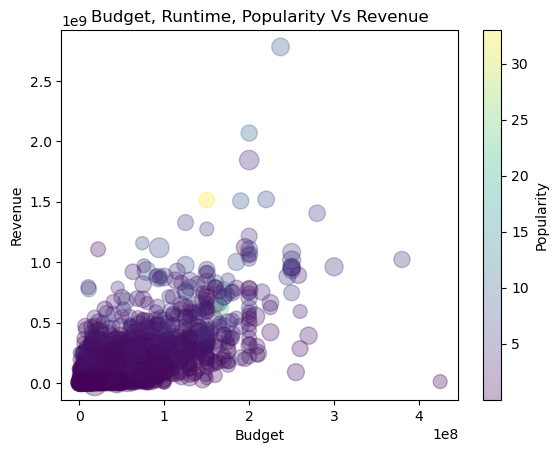

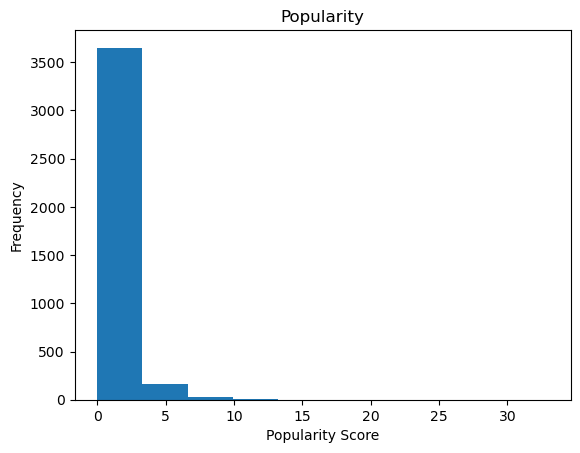

In [14]:

# dependent variable = Revenue
# independent variables = budget, runtime, popularity

# Scatter plot: budget on x axis, revenue on y axis, size
#for runtime. Color for popularity. 4D approach

# 4D
scatter_plot = plt.scatter(filtered_df['budget'], filtered_df['revenue'], s=filtered_df['runtime'],
            c=filtered_df['popularity'], cmap='viridis', alpha=0.3)

label_plot("Budget, Runtime, Popularity Vs Revenue", "Budget", "Revenue")

cbar = plt.colorbar(scatter_plot)

cbar.set_label("Popularity")

plt.show()

# 1D
histplot = plt.hist(filtered_df['popularity'])

label_plot("Popularity", "Popularity Score", "Frequency")


We can see that there is some correlation between budget and revenue up to a point. However to get really high revenue you just have to get lucky. Runtime (size) appears to have no noticeable impact. There are not that many popular movies, as evidenced in the 2nd graph, but we can see that the really popular ones are drowned out in the cluster of average movies and therefore popularity does not indicate high earnings.

Second graph simply shows that there are more unpopular/unknown movies then there are popular ones.

In [15]:
selected_columns = filtered_df[['budget', 'runtime', 'popularity', 'revenue']]
selected_columns.describe()

,budget,runtime,popularity,revenue
count,3.854000e+03,3854.000000,3854.000000,3.854000e+03
mean,3.720370e+07,109.220291,1.191554,1.076866e+08
std,4.220822e+07,19.922820,1.475162,1.765393e+08
min,1.000000e+00,15.000000,0.001117,2.000000e+00
25%,1.000000e+07,95.000000,0.462367,1.360003e+07
50%,2.400000e+07,106.000000,0.797511,4.480000e+07
75%,5.000000e+07,119.000000,1.368324,1.242125e+08
max,4.250000e+08,338.000000,32.985763,2.781506e+09


Max. revenue is $2,780,000,000 and the average is $107,686,600. The record holder is about 25 times more. This could mean that the "big hits" are pushing the average up and doesn't necessarily mean all movies on average will make $100 million. We can find evidence of this in the median (50%) which is $44,800,000. The scatterplot reflects how most movies made between $0 and $500,000,000. Using mean alone to predict a movie's success is risky because it is actually an "above average" amount.

### Which movie genres are the most popular, and which ones generate the highest average adjusted revenue?

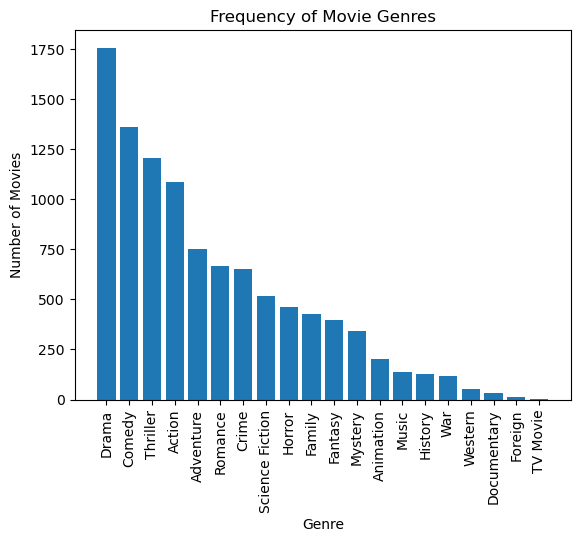

In [16]:
# 1. Plot the frequency of each genre in a bar chart

# Counts the genres
genre_counts = filtered_df['genres'].str.split('|').explode().value_counts()

# Generate the bar chart
plt.bar(genre_counts.index, genre_counts.values)

# Rotate the genre labels
plt.xticks(rotation = 90)

# Add labels and title
label_plot("Frequency of Movie Genres", "Genre", "Number of Movies")

# Display the plot
plt.show()

The above graph shows us that there are more Drama movies than any other genre. However this doesn't tell us that Drama is the most popular genre.

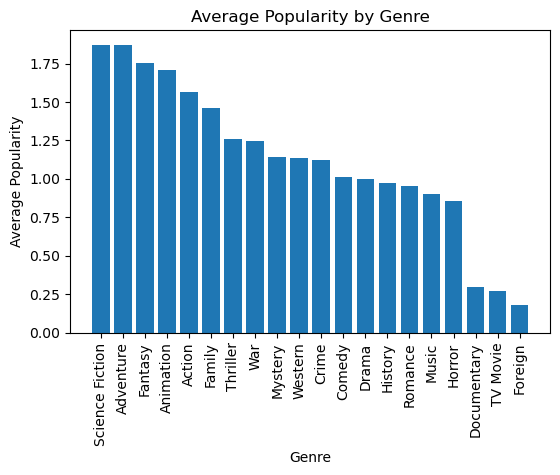

In [17]:
# 2. Finding the most popular genres (2D analysis)

# Since many movies have multiple genres like Action | Adventure, we need to first split them and duplicate the rows (movies) for each individual genre
exploded_df = filtered_df.assign(genres=filtered_df['genres'].str.split('|')).explode('genres')

# Calculating the average popularity and sorting it from highest to lowest
mean_pop = exploded_df.groupby('genres')['popularity'].mean().sort_values(ascending=False)

# Plotting the sorted data
plt.bar(mean_pop.index, mean_pop.values)
plt.xticks(rotation=90)

label_plot("Average Popularity by Genre", "Genre", "Average Popularity")

plt.subplots_adjust(bottom=0.25, left=0.15)


plt.show()

Since each movie row has a popularity score, I used that to derive the average popularity by grouping each genre. Here we can see Science Fiction movies are the most popular. 

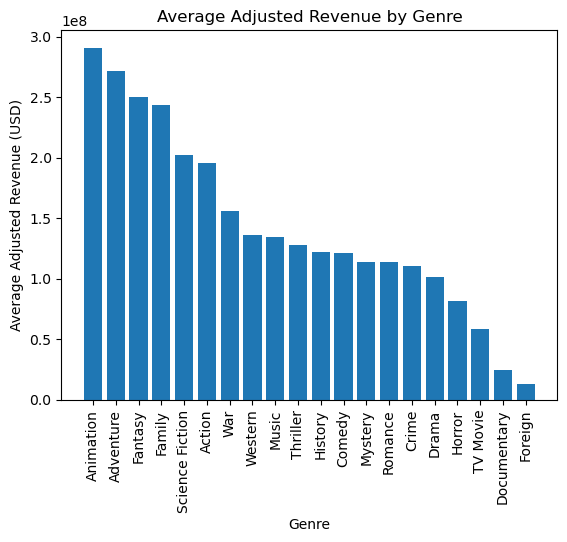

In [20]:
# 3. Finding which genres generated the highest adjusted revenue

# Find the average revenue for each genre and sort from highest to lowest
mean_revenue = exploded_df.groupby('genres')['revenue_adj'].mean().sort_values(ascending=False)

plt.bar(mean_revenue.index, mean_revenue.values)
plt.xticks(rotation=90)
label_plot("Average Adjusted Revenue by Genre", "Genre", "Average Adjusted Revenue (USD)")
plt.show()

Finally, we can see that although Science Fiction is the most popular genre, Animation leads the way in terms of average revenue earned. This means that popular genres don't necessarily make more money. 

### Has the average runtime of movies changed over the years, and is there a correlation between runtime and viewer ratings?

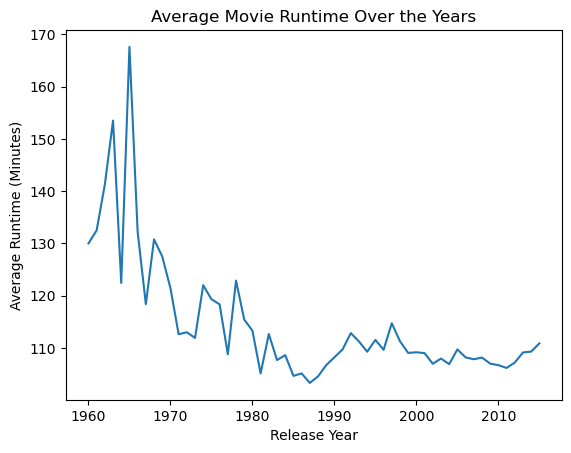

In [21]:
# 1. Has the average runtime changed over the years?

# Calculate the average runtime per year
runtime_by_year = filtered_df.groupby('release_year')['runtime'].mean()

# Generate a line plot
plt.plot(runtime_by_year.index, runtime_by_year.values)
label_plot("Average Movie Runtime Over the Years", "Release Year", "Average Runtime (Minutes)")

plt.show()

We can see that movies tended to be longer back then, with a noticeable spike in runtime length in the mid-1960s. It's worth noting that there may also be less movies from the 60s in the data, with outliers making that spike happen. Let's see if that's true...

In [22]:
# I'm checking 3 things: the number of movies from that decase, the statistical distribution, and a visual box plot

# Filter the dataset for the 1960s
sixties_movies = filtered_df[(filtered_df['release_year'] >= 1960) & (filtered_df['release_year'] <= 1969)]

# Inspect the distribution and sample size
sixties_movies['runtime'].describe()

count     71.000000
mean     133.338028
std       32.647005
min       78.000000
25%      110.500000
50%      128.000000
75%      151.000000
max      248.000000
Name: runtime, dtype: float64

- There were only 71 movies from that decade in the dataset
- The mean is significantly higher than the median
- The longest movie is 248 minutes, over 4 hours long, which is an extreme outlier...

In [25]:
# Counting the number of movies per decade
filtered_df.groupby((filtered_df['release_year'] // 10) * 10)['runtime'].count()

release_year
1960      71
1970     133
1980     395
1990     755
2000    1460
2010    1040
Name: runtime, dtype: int64

The 60s have noticeably fewer movies than all other decades.

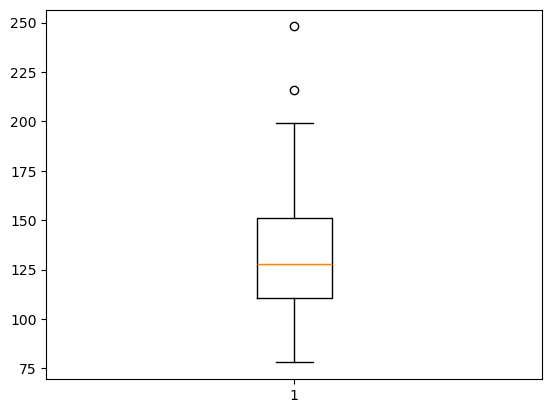

In [ ]:
plt.boxplot(sixties_movies['runtime'])
plt.show()

The box represents the middle 50% of the data (where most of it lies). The whiskers show the minimum and maximum normal values. Any values outside of the whiskers are outliers, and we can see 2 with very long runtimes. The median sits at around 125, which proves the spike we saw earlier is false, average movie runtimes in the 60s were not nearing 170 but more close to 125.



<a id='conclusions'></a>
## Conclusions

> **Tip**: Finally, summarize your findings and the results that have been performed in relation to the question(s) provided at the beginning of the analysis. Summarize the results accurately, and point out where additional research can be done or where additional information could be useful.

> **Tip**: Make sure that you are clear with regards to the limitations of your exploration. You should have at least 1 limitation explained clearly. 

> **Tip**: If you haven't done any statistical tests, do not imply any statistical conclusions. And make sure you avoid implying causation from correlation!

> **Tip**: Once you are satisfied with your work here, check over your report to make sure that it is satisfies all the areas of the rubric (found on the project submission page at the end of the lesson). You should also probably remove all of the "Tips" like this one so that the presentation is as polished as possible.

## Submitting your Project 

> **Tip**: Before you submit your project, you need to create a .html or .pdf version of this notebook in the workspace here. To do that, run the code cell below. If it worked correctly, you should see output that starts with `NbConvertApp] Converting notebook`, and you should see the generated .html file in the workspace directory (click on the orange Jupyter icon in the upper left).

> **Tip**: Alternatively, you can download this report as .html via the **File** > **Download as** submenu, and then manually upload it into the workspace directory by clicking on the orange Jupyter icon in the upper left, then using the Upload button.

> **Tip**: Once you've done this, you can submit your project by clicking on the "Submit Project" button in the lower right here. This will create and submit a zip file with this .ipynb doc and the .html or .pdf version you created. Congratulations!

In [18]:
# Running this cell will execute a bash command to convert this notebook to an .html file
!python -m nbconvert --to html Investigate_a_Dataset.ipynb

/Users/carlosvaleriano/Desktop/Upwork Portfolio/Udacity Portfolio/investigate_a_dataset/.conda/bin/python: No module named nbconvert
